# Comparativa variable a variable: observaciones (simulación vs monitor)

Gráficos de comparación entre las **variables de observación** del history y del monitor. **Ambas fuentes se filtran desde el inicio** al periodo **2026-03-04 12:15:48** a **2026-03-05 08:17:47**. Al final se incluye una **matriz de correlación** entre todas las variables y **t_supply / water_temperature**.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("data")
HISTORY_CSV = DATA_DIR / "ai-uponor_smatrix-alcorcon-lab_c7rqx7hm_history.csv"
MONITOR_DIR = DATA_DIR / "monitor_1"

In [63]:
# Periodo fijo: filtrar ambas fuentes desde el inicio
t_start = pd.Timestamp("2026-03-04 12:15:48.236082792")
t_end = pd.Timestamp("2026-03-05 08:17:47.552323103")

df_history = pd.read_csv(HISTORY_CSV)
df_obs = pd.read_csv(MONITOR_DIR / "observations.csv")
df_infos = pd.read_csv(MONITOR_DIR / "infos.csv")
df_actions = pd.read_csv(MONITOR_DIR / "simulated_actions.csv")

df_history["_datetime"] = pd.to_datetime(df_history["_timestamp"], unit="s")
df_history["_time_key"] = (
    df_history["_datetime"].dt.month.astype(str) + "-"
    + df_history["_datetime"].dt.day.astype(str) + "-"
    + df_history["_datetime"].dt.hour.astype(str)
)
year_ref = df_history["_datetime"].iloc[0].year
df_infos["_datetime"] = pd.to_datetime(
    dict(year=year_ref, month=df_infos["month"], day=df_infos["day"], hour=df_infos["hour"])
)
df_infos["_time_key"] = (
    df_infos["month"].astype(str) + "-" + df_infos["day"].astype(str) + "-" + df_infos["hour"].astype(str)
)

# Filtrar al periodo en ambas fuentes
mask_h = (df_history["_datetime"] >= t_start) & (df_history["_datetime"] <= t_end)
mask_m = (df_infos["_datetime"] >= t_start) & (df_infos["_datetime"] <= t_end)
df_history = df_history.loc[mask_h].copy()
df_infos = df_infos.loc[mask_m].copy()
df_obs = df_obs.loc[df_obs.index.isin(df_infos.index)].copy()
# actions: mantener solo filas cuyo índice está en infos filtrado y asignar _time_key
df_actions = df_actions.loc[df_actions.index.isin(df_infos.index)].copy()
df_actions["_time_key"] = df_infos.loc[df_actions.index, "_time_key"].values

common_keys = sorted(set(df_history["_time_key"].dropna()) & set(df_infos["_time_key"].dropna()))
n_compare = len(common_keys)
print("Periodo:", t_start, "a", t_end)
print("Filas history en periodo:", len(df_history), "| Filas monitor (infos/obs) en periodo:", len(df_infos))
print("Claves hora comunes:", n_compare)

Periodo: 2026-03-04 12:15:48.236082792 a 2026-03-05 08:17:47.552323103
Filas history en periodo: 41 | Filas monitor (infos/obs) en periodo: 40
Claves hora comunes: 20


In [64]:
OBS_MAPPING = {
    "air_temperature_f0_bathroom": "air_temperature_f0_bathroom-lobby",
    "air_temperature_f0_livroom-kitchen": "air_temperature_f0_living-kitchen",
    "air_temperature_f1_bed1": "air_temperature_f1_bedroom1",
    "air_temperature_f1_bed2": "air_temperature_f1_bedroom2",
    "air_temperature_f1_bed3": "air_temperature_f1_bedroom3",
    "air_temperature_f1_main_bathroom": "air_temperature_f1_bathroom-corridor",
    "air_temperature_f1_secondary_bathroom": "air_temperature_f1_bathroom-dressing",
    "air_humidity_f0_bathroom": "air_humidity_f0_bathroom-lobby",
    "air_humidity_f0_livroom-kitchen": "air_humidity_f0_living-kitchen",
    "air_humidity_f1_bed1": "air_humidity_f1_bedroom1",
    "air_humidity_f1_bed2": "air_humidity_f1_bedroom2",
    "air_humidity_f1_bed3": "air_humidity_f1_bedroom3",
    "air_humidity_f1_main_bathroom": "air_humidity_f1_bathroom-corridor",
    "air_humidity_f1_secondary_bathroom": "air_humidity_f1_bathroom-dressing",
    "setpoint_f0_bathroom": "heating_setpoint_f0_bathroom-lobby",
    "setpoint_f0_livroom-kitchen": "heating_setpoint_f0_living-kitchen",
    "setpoint_f1_bed1": "heating_setpoint_f1_bedroom1",
    "setpoint_f1_bed2": "heating_setpoint_f1_bedroom2",
    "setpoint_f1_bed3": "heating_setpoint_f1_bedroom3",
    "setpoint_f1_main_bathroom": "heating_setpoint_f1_bathroom-corridor",
    "setpoint_f1_secondary_bathroom": "heating_setpoint_f1_bathroom-dressing",
    "outdoor_temperature": "outdoor_temperature",
    "outdoor_humidity": "outdoor_humidity",
    "wind_speed": "wind_speed",
    "wind_direction": "wind_direction",
    "direct_solar_radiation": "direct_solar_radiation",
    "diffuse_solar_radiation": "diffuse_solar_radiation",
    "month_cos": "month_cos", "month_sin": "month_sin", "day_cos": "day_cos", "day_sin": "day_sin",
    "hour_cos": "hour_cos", "hour_sin": "hour_sin",
    "heat_pump_load_side_outlet_temp": "heat_source_load_side_outlet_temp",
    "heat_pump_electricity_rate": "heat_source_electricity_rate",
}

hist_mask = df_history["_time_key"].isin(common_keys)
mon_mask = df_infos["_time_key"].isin(common_keys)

df_hist_h = df_history.loc[hist_mask].groupby("_time_key", sort=True).mean(numeric_only=True).reindex(common_keys)

def agg_monitor_by_key(df, keys, time_key_series, mask):
    rows = []
    for k in keys:
        ii = mask & (time_key_series == k)
        idx = time_key_series.index[ii].intersection(df.index)
        if len(idx):
            rows.append(df.loc[idx].mean(numeric_only=True))
        else:
            rows.append(pd.Series(dtype=float))
    return pd.DataFrame(rows, index=keys)

mon_mask = df_infos["_time_key"].isin(common_keys)
df_mon_h = agg_monitor_by_key(df_obs, common_keys, df_infos["_time_key"], mon_mask)
mon_mask_act = df_actions["_time_key"].isin(common_keys)
df_act_h = agg_monitor_by_key(df_actions, common_keys, df_actions["_time_key"], mon_mask_act)

time_axis = df_history.loc[hist_mask].groupby("_time_key", sort=True)["_datetime"].first().reindex(common_keys).values
print("Datos agregados por hora.")

Datos agregados por hora.


In [65]:
df_act_h

,flow_rate_f0_living-kitchen,flow_rate_f0_bathroom-lobby,flow_rate_f1_bedroom1,flow_rate_f1_bedroom2,flow_rate_f1_bedroom3,flow_rate_f1_bathroom-corridor,flow_rate_f1_bathroom-dressing,water_temperature
3-4-13,0.0,0.0,0.5,0.0,0.0,0.0,0.0,27.001235
3-4-14,0.0,0.0,0.0,0.0,0.5,0.0,0.5,26.724221
3-4-15,0.0,0.0,0.0,0.0,0.0,0.0,0.5,26.814830
3-4-16,0.0,0.0,0.0,0.0,0.5,0.0,0.0,26.847067
3-4-17,0.0,0.5,0.0,1.0,0.0,0.0,0.0,26.882318
3-4-18,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.675377
3-4-19,0.0,1.0,0.0,1.0,0.0,0.0,0.0,26.549068
3-4-20,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.621316
3-4-21,0.0,1.0,0.0,0.5,0.0,1.0,0.0,27.245476
3-4-22,0.0,0.5,0.5,0.5,0.5,0.5,0.0,27.888815


## Gráficos variable a variable (simulación vs monitor)

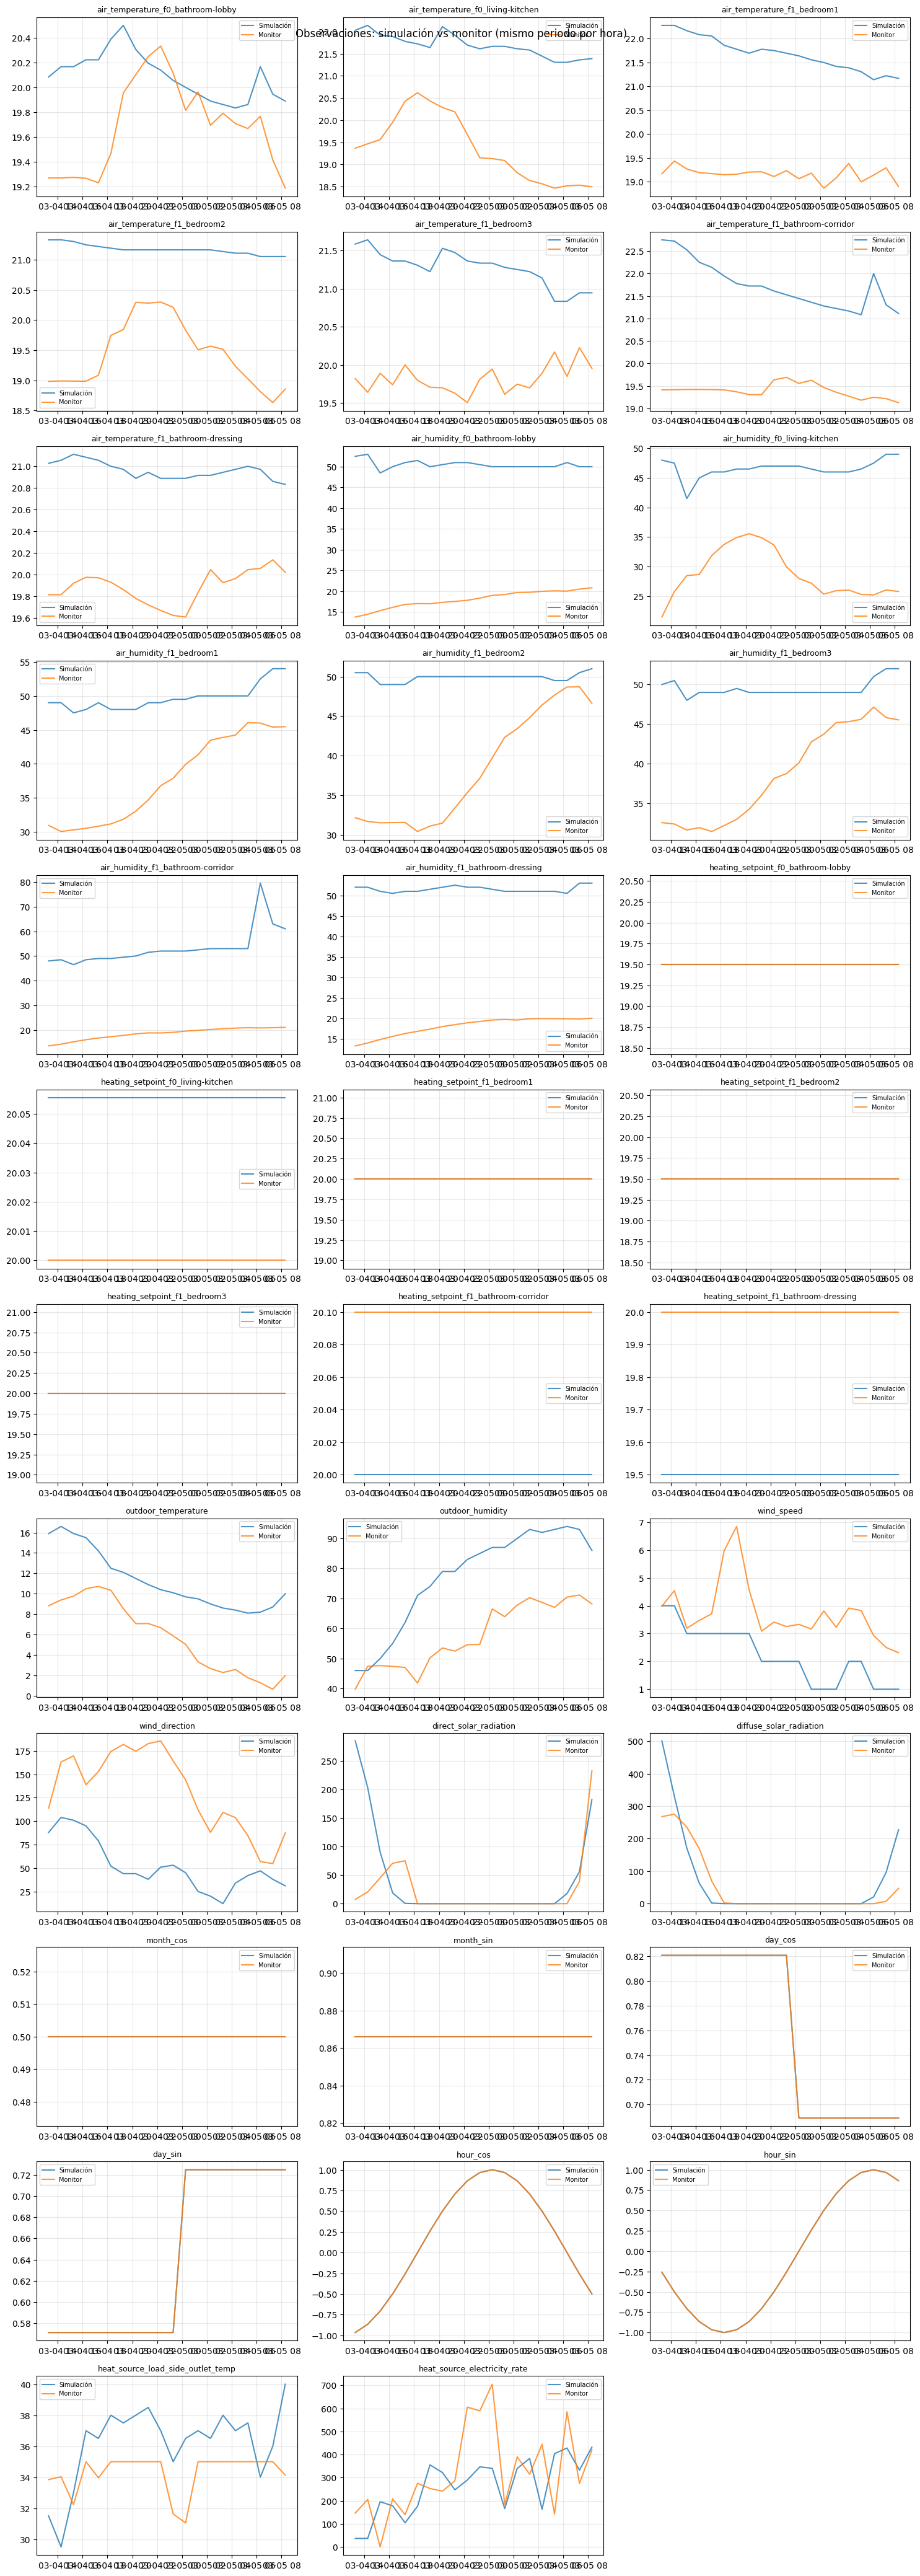

In [66]:
variable_pairs = []
for h_name, m_name in OBS_MAPPING.items():
    col_h = f"observation/{h_name}"
    if col_h in df_hist_h.columns and m_name in df_mon_h.columns:
        variable_pairs.append((h_name, m_name, col_h))

n_vars = len(variable_pairs)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

x_axis = np.arange(n_compare) if (time_axis is None or pd.isna(time_axis).any()) else time_axis

for idx, (h_name, m_name, col_h) in enumerate(variable_pairs):
    ax = axes[idx]
    v_sim = df_hist_h[col_h].values
    v_mon = df_mon_h[m_name].values
    ax.plot(x_axis, v_sim, label="Simulación", alpha=0.8, color="C0")
    ax.plot(x_axis, v_mon, label="Monitor", alpha=0.8, color="C1")
    ax.set_title(m_name[:45] + ("..." if len(m_name) > 45 else ""), fontsize=9)
    ax.legend(loc="best", fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(len(variable_pairs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Observaciones: simulación vs monitor (mismo periodo por hora)", fontsize=12)
plt.tight_layout()
plt.show()

## Gráficos en bloques (por tipo de variable)

Se repiten los gráficos en grupos más pequeños para mejor legibilidad.

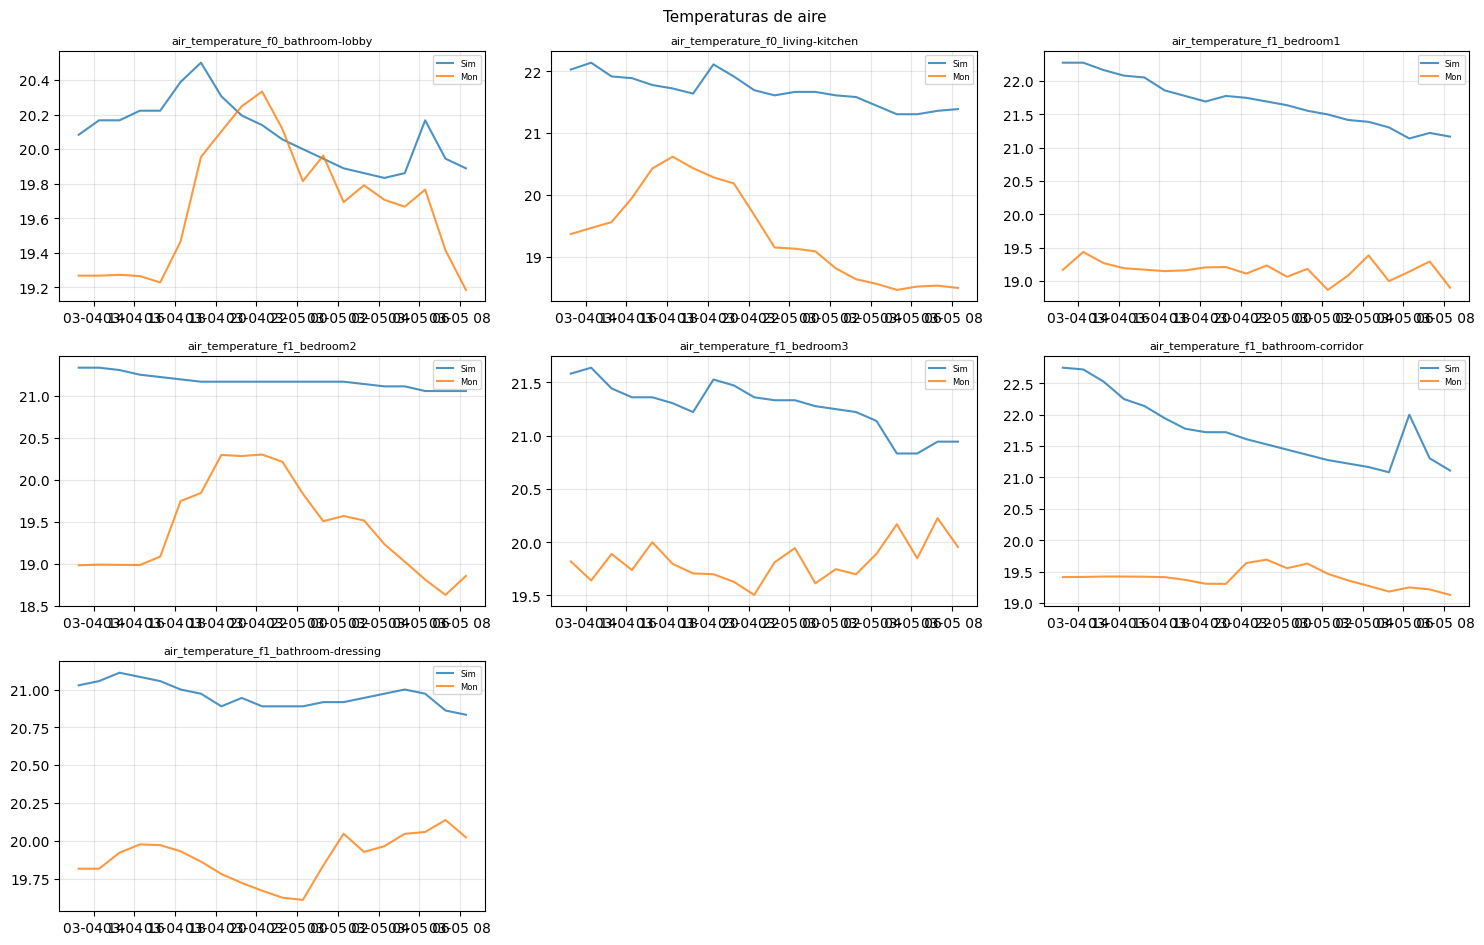

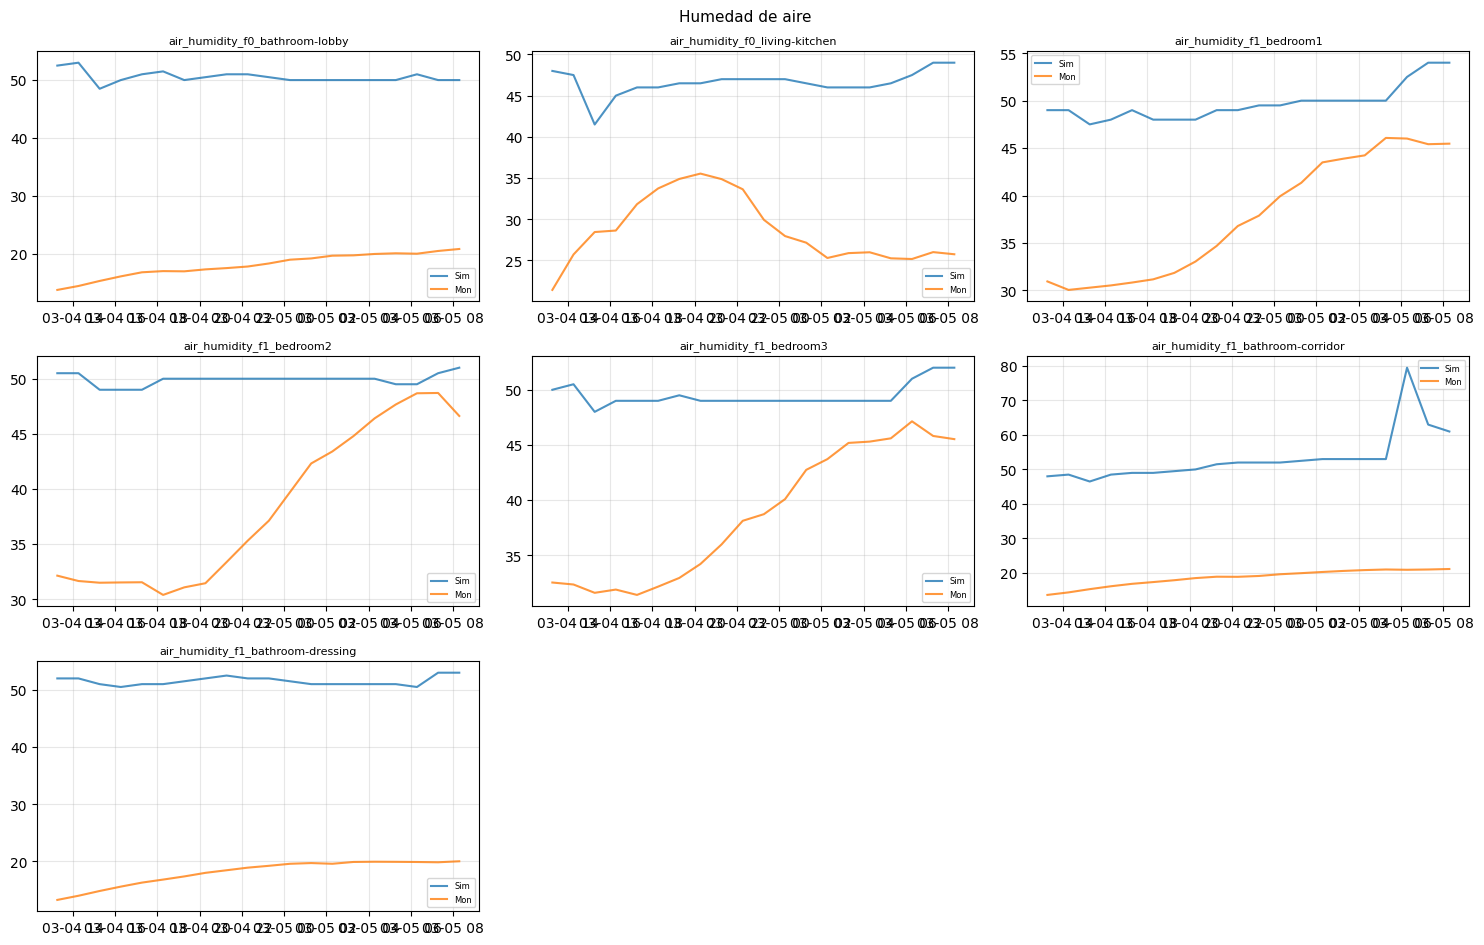

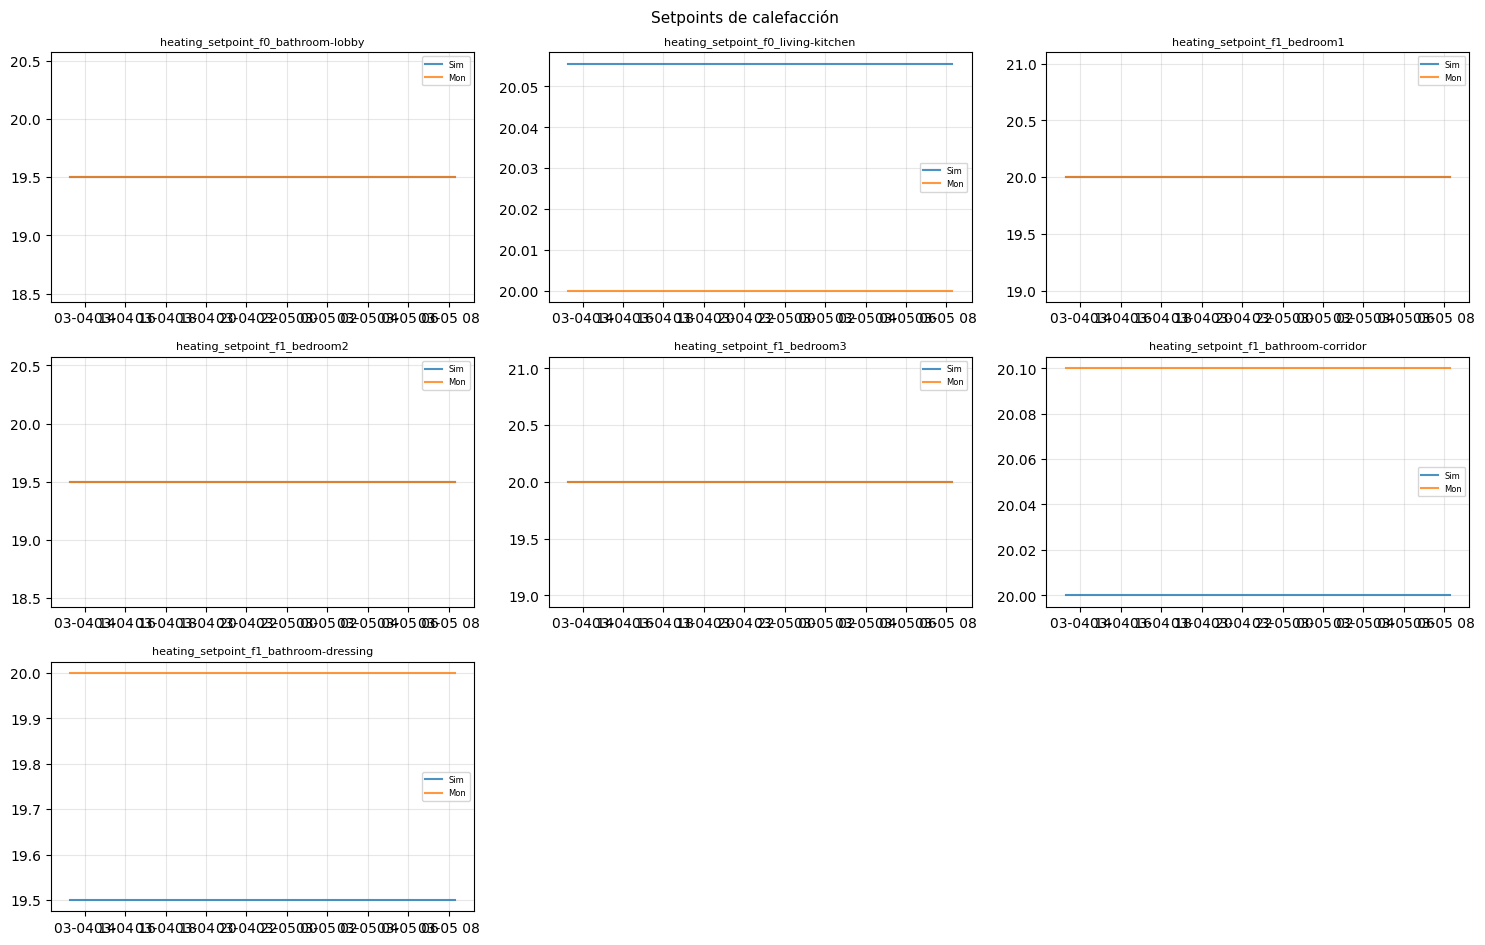

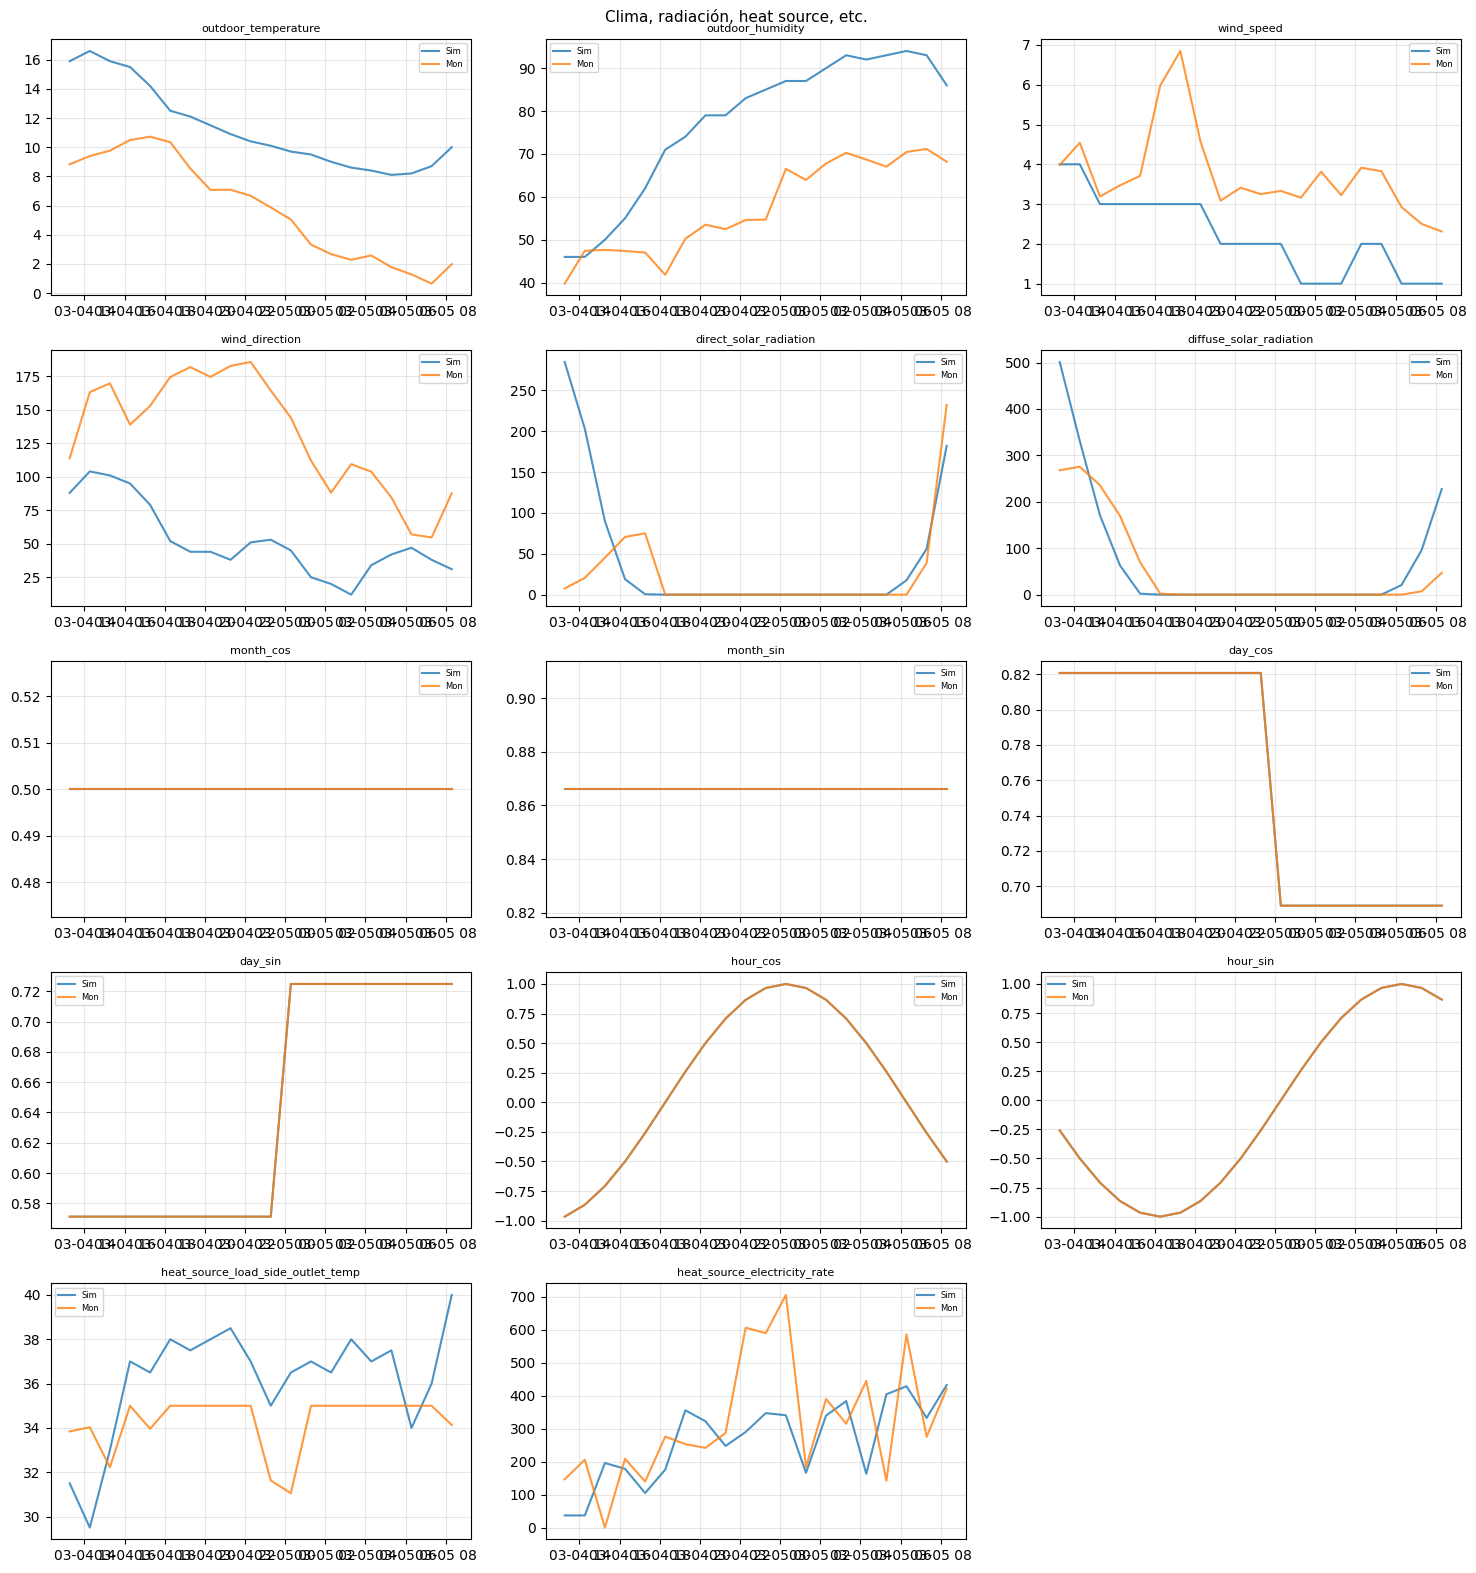

In [67]:
def plot_group(pairs_subset, title_part):
    n = len(pairs_subset)
    if n == 0:
        return
    nc = 3
    nr = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(5 * nc, 3.2 * nr))
    axes = np.atleast_2d(axes)
    axes = axes.flatten()
    x_axis = np.arange(n_compare) if (time_axis is None or pd.isna(time_axis).any()) else time_axis
    for i, (h_name, m_name, col_h) in enumerate(pairs_subset):
        ax = axes[i]
        ax.plot(x_axis, df_hist_h[col_h].values, label="Sim", color="C0", alpha=0.8)
        ax.plot(x_axis, df_mon_h[m_name].values, label="Mon", color="C1", alpha=0.8)
        ax.set_title(m_name[:42], fontsize=8)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(title_part, fontsize=11)
    plt.tight_layout()
    plt.show()

temp_pairs = [(h, m, c) for h, m, c in variable_pairs if "air_temperature" in m]
hum_pairs = [(h, m, c) for h, m, c in variable_pairs if "air_humidity" in m]
setp_pairs = [(h, m, c) for h, m, c in variable_pairs if "setpoint" in h or "heating_setpoint" in m]
other_pairs = [(h, m, c) for h, m, c in variable_pairs if (h, m, c) not in temp_pairs + hum_pairs + setp_pairs]

plot_group(temp_pairs, "Temperaturas de aire")
plot_group(hum_pairs, "Humedad de aire")
plot_group(setp_pairs, "Setpoints de calefacción")
plot_group(other_pairs, "Clima, radiación, heat source, etc.")

## Matriz de correlación (todas las variables + t_supply / water_temperature)

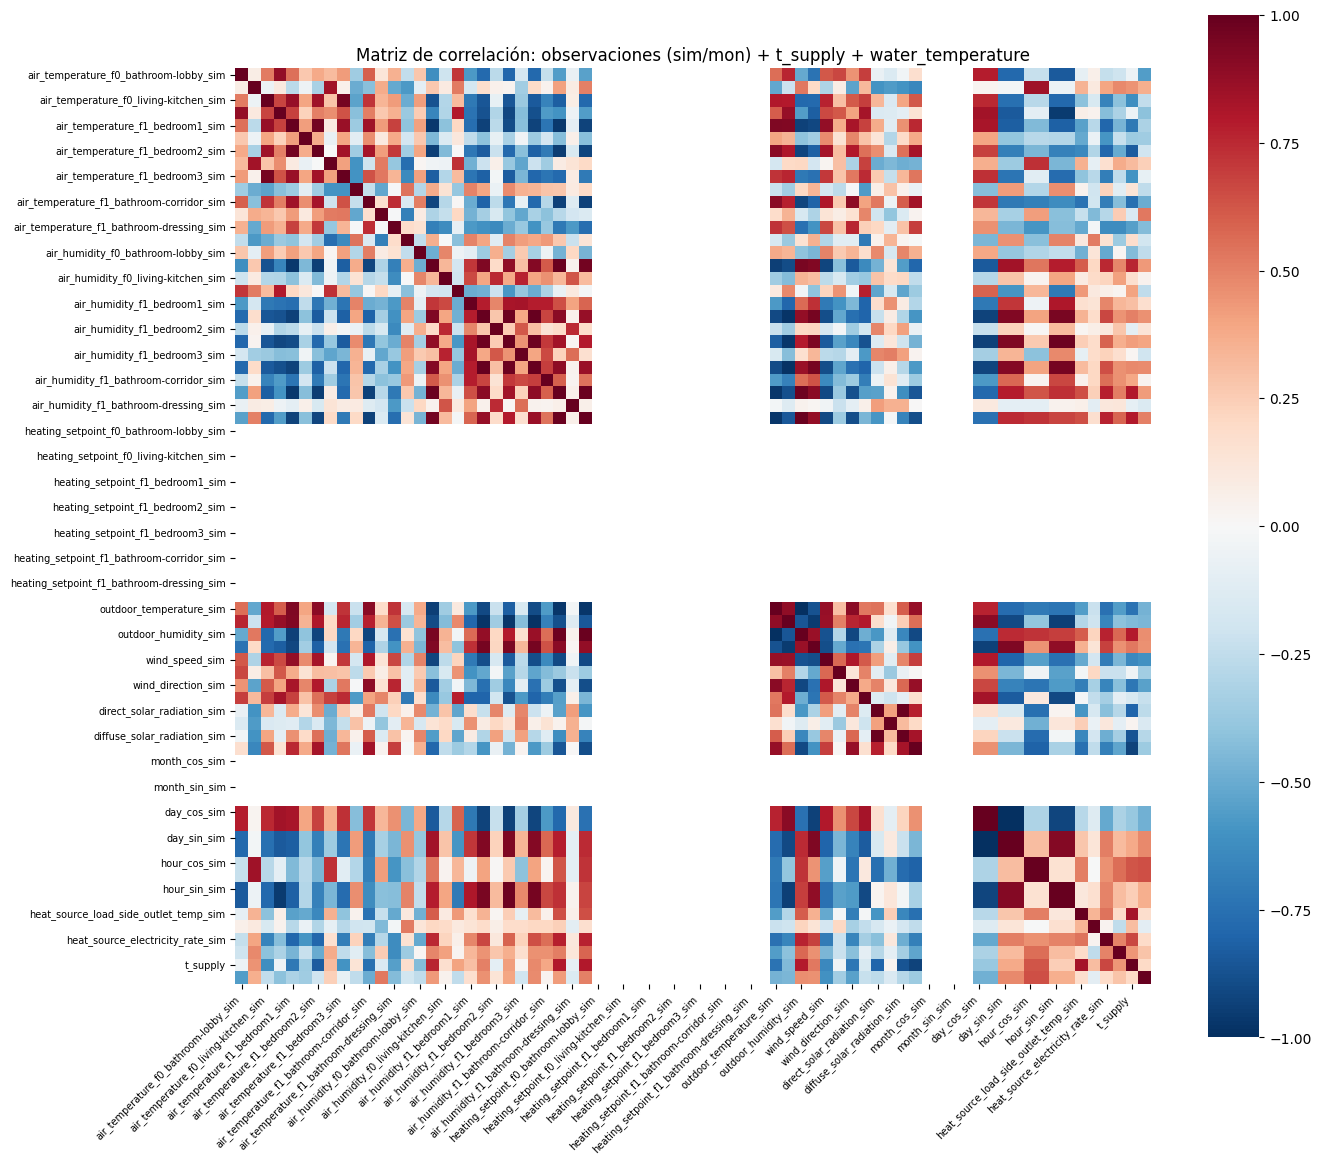

In [68]:
# DataFrame unificado: una fila por hora común, columnas = observaciones (nombres monitor) + t_supply + water_temperature
cols_corr = []
data_corr = {}

for h_name, m_name in OBS_MAPPING.items():
    col_h = f"observation/{h_name}"
    if col_h not in df_hist_h.columns or m_name not in df_mon_h.columns:
        continue
    cols_corr.append(m_name)
    data_corr[m_name + "_sim"] = df_hist_h[col_h].values
    data_corr[m_name + "_mon"] = df_mon_h[m_name].values

data_corr["t_supply"] = df_hist_h["info/t_supply"].values if "info/t_supply" in df_hist_h.columns else np.nan
data_corr["water_temperature"] = df_act_h["water_temperature"].values if "water_temperature" in df_act_h.columns else np.nan
cols_corr.extend(["t_supply", "water_temperature"])

df_corr = pd.DataFrame(data_corr)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Matriz de correlación: observaciones (sim/mon) + t_supply + water_temperature")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [69]:
# Correlaciones con t_supply y con water_temperature (ordenadas por |r|)
if "t_supply" in corr_matrix.columns:
    r_t_supply = corr_matrix["t_supply"].drop(["t_supply", "water_temperature"], errors="ignore")
    r_t_supply = r_t_supply.reindex(r_t_supply.abs().sort_values(ascending=False).index)
    print("=== Correlación con t_supply (simulación) ===")
    print(r_t_supply.head(25).to_string())
if "water_temperature" in corr_matrix.columns:
    r_water = corr_matrix["water_temperature"].drop(["t_supply", "water_temperature"], errors="ignore")
    r_water = r_water.reindex(r_water.abs().sort_values(ascending=False).index)
    print("\n=== Correlación con water_temperature (monitor) ===")
    print(r_water.head(25).to_string())

=== Correlación con t_supply (simulación) ===
diffuse_solar_radiation_mon                -0.922562
diffuse_solar_radiation_sim                -0.859458
heat_source_load_side_outlet_temp_sim       0.834678
air_temperature_f1_bedroom2_sim            -0.829367
air_humidity_f1_bathroom-dressing_mon       0.803528
direct_solar_radiation_sim                 -0.799476
air_humidity_f1_bathroom-corridor_mon       0.798685
outdoor_humidity_sim                        0.790970
air_humidity_f0_bathroom-lobby_mon          0.761543
air_temperature_f1_bathroom-corridor_sim   -0.757504
outdoor_temperature_sim                    -0.739339
wind_direction_sim                         -0.724952
air_temperature_f1_bedroom1_sim            -0.711738
heat_source_electricity_rate_sim            0.668046
wind_speed_sim                             -0.642986
hour_cos_sim                                0.625401
hour_cos_mon                                0.625401
air_temperature_f0_living-kitchen_sim      -0.620940


In [ ]:
# Submatriz: solo variables de observación (nombres únicos) + t_supply y water_temperature
obs_cols_only = [c for c in corr_matrix.columns if c in ("t_supply", "water_temperature") or c.endswith("_sim") or c.endswith("_mon")]
target_cols = [c for c in corr_matrix.columns if c in ("t_supply", "water_temperature")]
if target_cols:
    sub = corr_matrix.loc[obs_cols_only, target_cols]
    sub = sub.reindex(sub[target_cols[0]].abs().sort_values(ascending=False).index)
    print("Correlación de cada variable con t_supply y water_temperature:")
    print(sub.round(4).to_string())

Correlación de cada variable con t_supply y water_temperature:
                                           t_supply  water_temperature
t_supply                                     1.0000             0.1962
diffuse_solar_radiation_mon                 -0.9226            -0.3597
diffuse_solar_radiation_sim                 -0.8595            -0.2823
heat_source_load_side_outlet_temp_sim        0.8347             0.1734
air_temperature_f1_bedroom2_sim             -0.8294            -0.1987
air_humidity_f1_bathroom-dressing_mon        0.8035             0.5028
direct_solar_radiation_sim                  -0.7995            -0.2618
air_humidity_f1_bathroom-corridor_mon        0.7987             0.4268
outdoor_humidity_sim                         0.7910             0.4644
air_humidity_f0_bathroom-lobby_mon           0.7615             0.4320
air_temperature_f1_bathroom-corridor_sim    -0.7575            -0.4980
outdoor_temperature_sim                     -0.7393            -0.4750
wind_direction

## Comparativa: info valves (simulación) vs flow_rates (monitor)

Las columnas **info/valve_*** del history representan el estado de las válvulas; en el monitor el equivalente son los **flow_rate_*** (caudal). Aquí se comparan variable a variable en el mismo periodo.

In [ ]:
# Mapeo info/valve_* (history) -> flow_rate_* (monitor)
VALVE_TO_FLOW = {
    "valve_f0_bathroom": "flow_rate_f0_bathroom-lobby",
    "valve_f0_livroom-kitchen": "flow_rate_f0_living-kitchen",
    "valve_f1_bed1": "flow_rate_f1_bedroom1",
    "valve_f1_bed2": "flow_rate_f1_bedroom2",
    "valve_f1_bed3": "flow_rate_f1_bedroom3",
    "valve_f1_main_bathroom": "flow_rate_f1_bathroom-corridor",
    "valve_f1_secondary_bathroom": "flow_rate_f1_bathroom-dressing",
}

# Pares (columna info en history, columna flow_rate en monitor) que existan en ambos
valve_flow_pairs = []
for v_name, f_name in VALVE_TO_FLOW.items():
    col_info = f"info/{v_name}"
    if col_info in df_hist_h.columns and f_name in df_act_h.columns:
        valve_flow_pairs.append((v_name, f_name, col_info))
print("Pares valve (info) vs flow_rate:", len(valve_flow_pairs))

Pares valve (info) vs flow_rate: 7


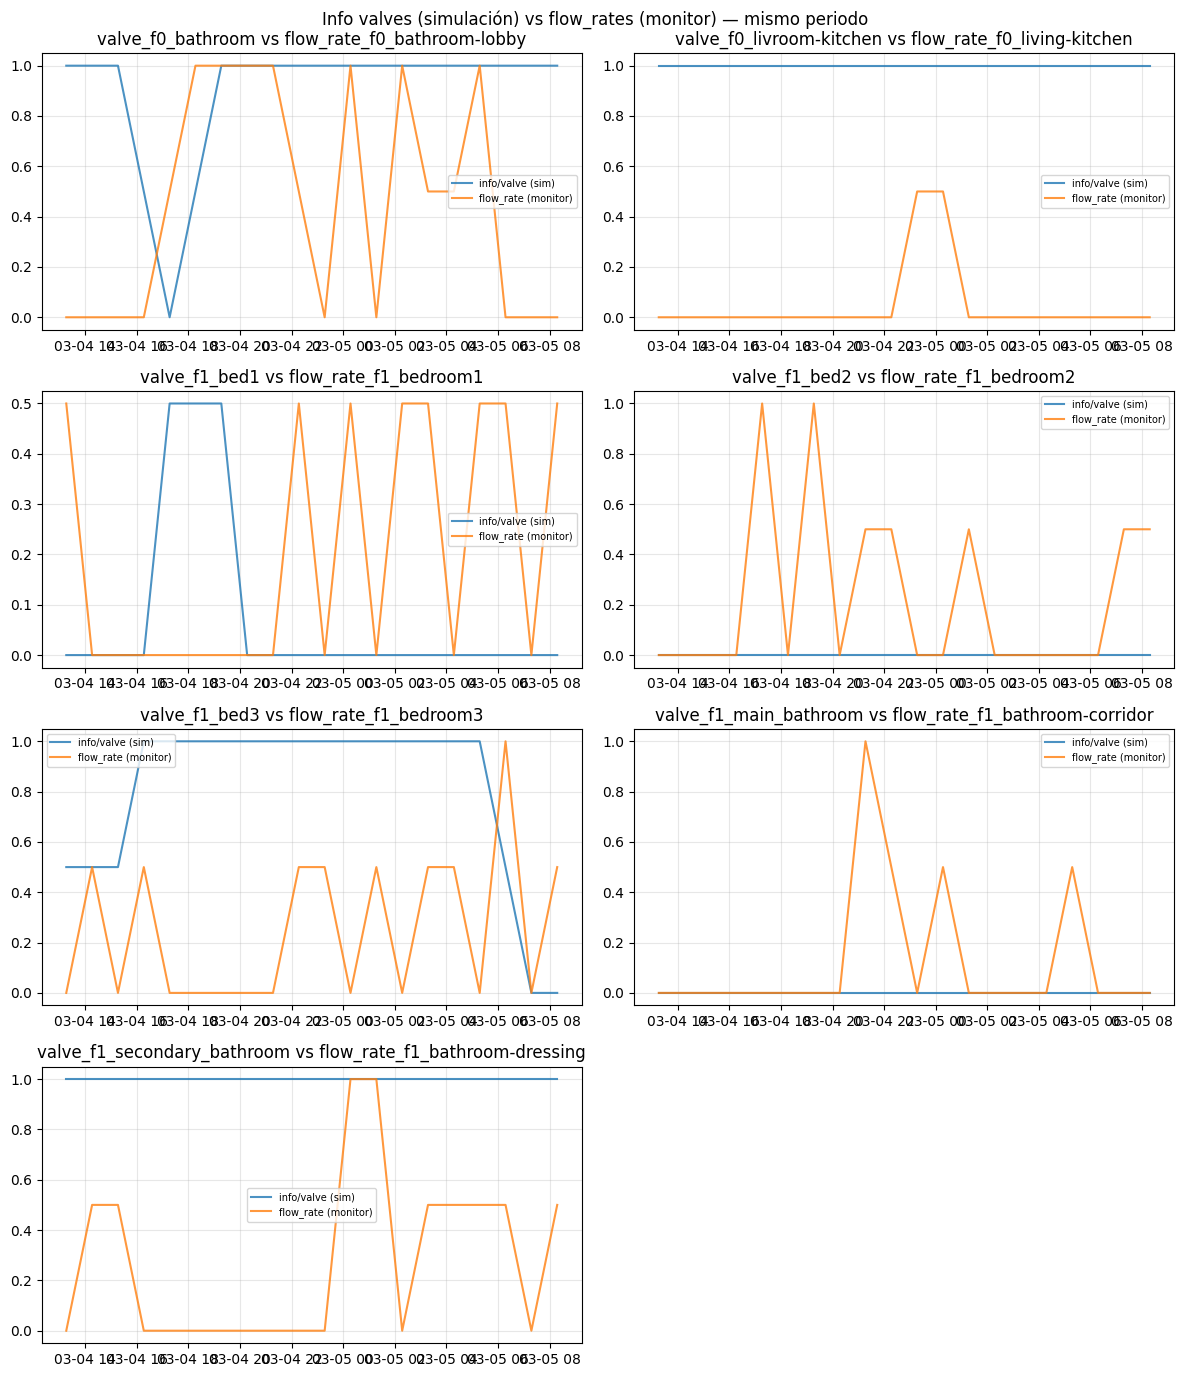

In [72]:
# Gráficos variable a variable: info valve vs flow_rate
if len(valve_flow_pairs) == 0:
    print("No hay columnas info/valve o flow_rate en los datos agregados.")
else:
    nvf = len(valve_flow_pairs)
    nc, nr = 2, (nvf + 1) // 2
    fig, axes = plt.subplots(nr, nc, figsize=(6 * nc, 3.5 * nr))
    axes = np.atleast_2d(axes)
    axes = axes.flatten()
    x_axis = np.arange(n_compare) if (time_axis is None or pd.isna(time_axis).any()) else time_axis
    for i, (v_name, f_name, col_info) in enumerate(valve_flow_pairs):
        ax = axes[i]
        v_sim = df_hist_h[col_info].values
        v_mon = df_act_h[f_name].values
        ax.plot(x_axis, v_sim, label="info/valve (sim)", color="C0", alpha=0.8)
        ax.plot(x_axis, v_mon, label="flow_rate (monitor)", color="C1", alpha=0.8)
        ax.set_title(f"{v_name} vs {f_name}")
        ax.legend(loc="best", fontsize=7)
        ax.grid(True, alpha=0.3)
    for j in range(len(valve_flow_pairs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Info valves (simulación) vs flow_rates (monitor) — mismo periodo")
    plt.tight_layout()
    plt.show()

In [ ]:
df_act_h

,flow_rate_f0_living-kitchen,flow_rate_f0_bathroom-lobby,flow_rate_f1_bedroom1,flow_rate_f1_bedroom2,flow_rate_f1_bedroom3,flow_rate_f1_bathroom-corridor,flow_rate_f1_bathroom-dressing,water_temperature
3-4-13,0.0,0.0,0.5,0.0,0.0,0.0,0.0,27.001235
3-4-14,0.0,0.0,0.0,0.0,0.5,0.0,0.5,26.724221
3-4-15,0.0,0.0,0.0,0.0,0.0,0.0,0.5,26.814830
3-4-16,0.0,0.0,0.0,0.0,0.5,0.0,0.0,26.847067
3-4-17,0.0,0.5,0.0,1.0,0.0,0.0,0.0,26.882318
3-4-18,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.675377
3-4-19,0.0,1.0,0.0,1.0,0.0,0.0,0.0,26.549068
3-4-20,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.621316
3-4-21,0.0,1.0,0.0,0.5,0.0,1.0,0.0,27.245476
3-4-22,0.0,0.5,0.5,0.5,0.5,0.5,0.0,27.888815


/usr/local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


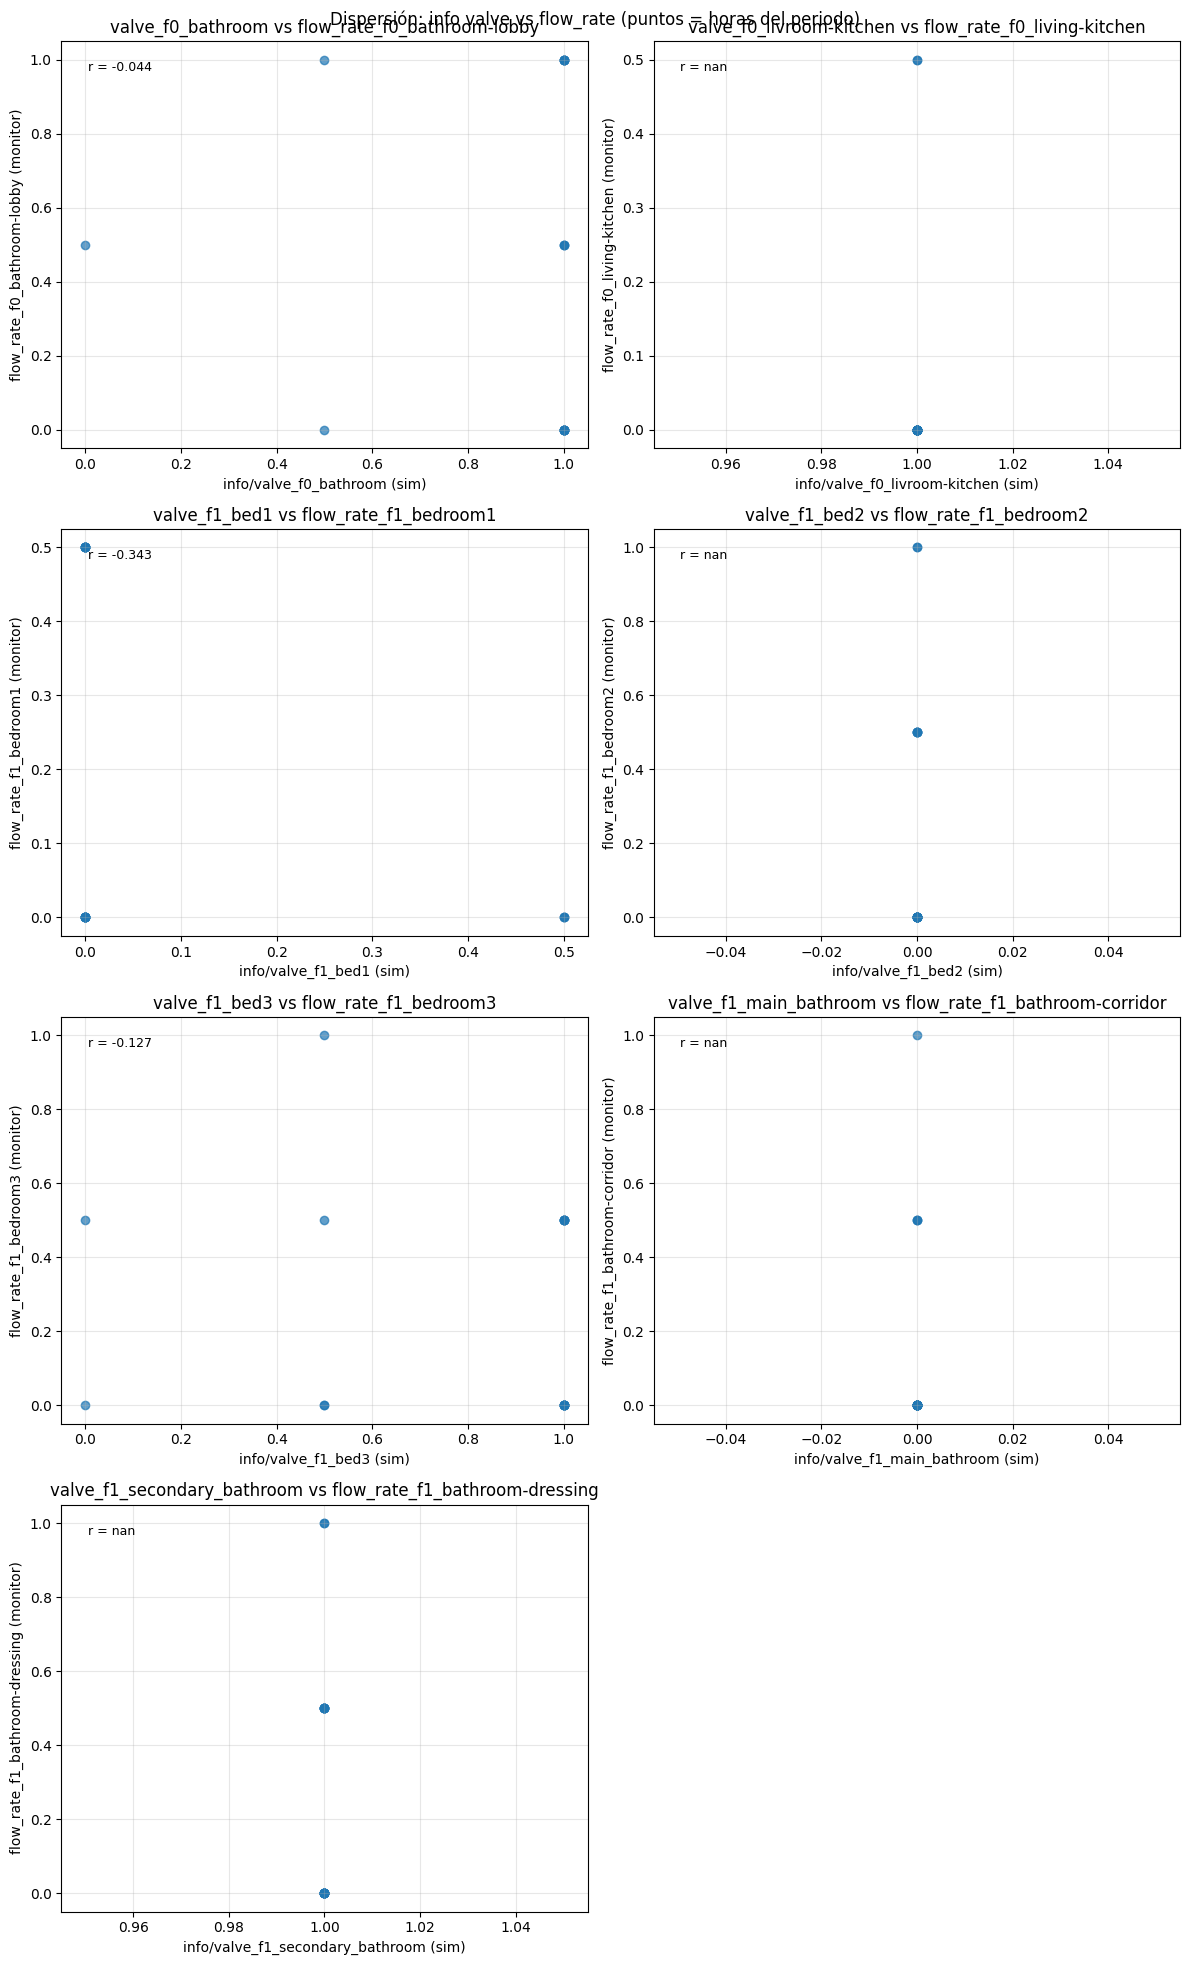

In [74]:
# Scatter: valor info/valve (eje x) vs flow_rate (eje y) por zona
if len(valve_flow_pairs) > 0:
    nvf = len(valve_flow_pairs)
    nc, nr = 2, (nvf + 1) // 2
    fig, axes = plt.subplots(nr, nc, figsize=(6 * nc, 5 * nr))
    axes = np.atleast_2d(axes)
    axes = axes.flatten()
    for i, (v_name, f_name, col_info) in enumerate(valve_flow_pairs):
        ax = axes[i]
        x = df_hist_h[col_info].values
        y = df_act_h[f_name].values
        ax.scatter(x, y, alpha=0.7)
        ax.set_xlabel(f"info/{v_name} (sim)")
        ax.set_ylabel(f"{f_name} (monitor)")
        ax.set_title(f"{v_name} vs {f_name}")
        if len(x) > 1:
            r = np.corrcoef(x, y)[0, 1]
            ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes, fontsize=9, verticalalignment="top")
        ax.grid(True, alpha=0.3)
    for j in range(len(valve_flow_pairs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Dispersión: info valve vs flow_rate (puntos = horas del periodo)")
    plt.tight_layout()
    plt.show()

In [75]:
# Resumen: estadísticas y correlación valve (info) vs flow_rate
if len(valve_flow_pairs) > 0:
    rows = []
    for v_name, f_name, col_info in valve_flow_pairs:
        x = df_hist_h[col_info].values
        y = df_act_h[f_name].values
        r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
        rows.append({
            "valve (info)": v_name,
            "flow_rate (monitor)": f_name,
            "mean_valve_sim": np.nanmean(x),
            "mean_flow_mon": np.nanmean(y),
            "corr_r": r,
        })
    df_valve_flow = pd.DataFrame(rows)
    print("Comparativa info valves vs flow_rates (periodo filtrado):\n")
    print(df_valve_flow.round(4).to_string(index=False))

Comparativa info valves vs flow_rates (periodo filtrado):

               valve (info)            flow_rate (monitor)  mean_valve_sim  mean_flow_mon  corr_r
          valve_f0_bathroom    flow_rate_f0_bathroom-lobby           0.900          0.450 -0.0441
   valve_f0_livroom-kitchen    flow_rate_f0_living-kitchen           1.000          0.050     NaN
              valve_f1_bed1          flow_rate_f1_bedroom1           0.075          0.200 -0.3430
              valve_f1_bed2          flow_rate_f1_bedroom2           0.000          0.225     NaN
              valve_f1_bed3          flow_rate_f1_bedroom3           0.800          0.250 -0.1274
     valve_f1_main_bathroom flow_rate_f1_bathroom-corridor           0.000          0.125     NaN
valve_f1_secondary_bathroom flow_rate_f1_bathroom-dressing           1.000          0.275     NaN
